<a href="https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t111_esm3_protein_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t111_esm3_protein_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESM3 — 생성형 단백질 설계

**Day 06 · 단백질 언어모델 실습**

[EvolutionaryScale](https://www.evolutionaryscale.ai/)의 **ESM3** 로 마스킹한 구간의 서열을 설계하고,
같은 모델로 그 서열의 3D 구조와 신뢰도(pTM·pLDDT)까지 예측해 본다.


## 0. 실행 환경

- **GPU는 필수가 아닙니다** (CPU에서도 각 생성 단계가 15초 내외). GPU가 있으면 더 빠릅니다.
  Colab에서 GPU를 켜려면: 런타임 > 런타임 유형 변경 > 하드웨어 가속기 > T4 GPU
- 아래 셀이 ESM3 런타임 의존성을 먼저 확인해 **없는 것만** 설치하고, 연산 장치를 `DEVICE` 상수 하나로 고정합니다.
  이후 모든 셀은 `DEVICE` 만 참조합니다.
- ESM3 본체(`esm`) 만은 `--no-deps` 가 필요해 2절에서 따로 설치합니다 (이유는 2절 설명 참고).


In [1]:
import importlib, subprocess, sys

REQUIRED = {
    # "import 이름": "pip 패키지명"
    # esm 본체는 --no-deps 설치가 필요해 2절에서 따로 다룬다. 여기서는 esm 이
    # 런타임에 실제로 import 하는 의존성만 확인한다.
    "zstd": "zstd",                      # 가중치/토크나이저 압축 해제
    "msgpack_numpy": "msgpack-numpy",    # 텐서 직렬화
    "cloudpathlib": "cloudpathlib",      # 원격 체크포인트 경로 처리
    "tenacity": "tenacity",              # 다운로드 재시도
    "pygtrie": "pygtrie",                # 함수(function) 트랙 어휘 트라이
    "pydssp": "pydssp",                  # 2차구조 계산
    "brotli": "brotli",                  # 압축 해제
    "einops": "einops",                  # 텐서 재배열
    "biotite": "biotite>=1.0.0",         # 구조 파싱 / PDB 출력
    "Bio": "biopython",                  # esm.utils 가 요구 (없으면 ESM3 import 실패)
    "py3Dmol": "py3Dmol",                # 5절 구조 시각화
}

def ensure(packages: dict) -> list:
    """import 가능한지 먼저 확인하고, 없는 것만 pip로 설치한다."""
    missing = [pip_name for mod, pip_name in packages.items()
               if importlib.util.find_spec(mod) is None]
    if missing:
        print("설치 대상:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    else:
        print("모든 의존 패키지가 이미 준비되어 있습니다.")
    return missing

ensure(REQUIRED)


import torch

# 연산 장치는 이 상수 하나로 고정한다 (노트북 전체에서 DEVICE 만 사용)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("DEVICE =", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("[안내] CPU 런타임입니다. 실행은 되지만 각 생성 단계가 15초 내외로 느려집니다.")


설치 대상: zstd, msgpack-numpy, pygtrie, pydssp, biotite>=1.0.0, biopython, py3Dmol
Python: 3.13.15
PyTorch: 2.11.0+cpu
DEVICE = cpu
[안내] CPU 런타임입니다. 실행은 되지만 각 생성 단계가 15초 내외로 느려집니다.


## 1. 개요와 학습 목표

- **모델**: ESM3 는 단백질의 **서열(sequence) · 구조(structure) · 기능(function)** 세 트랙을
  하나의 모델로 다루는 생성형 멀티모달 모델이다. 여기서는 공개 소형 체크포인트 `esm3_sm_open_v1`(1.4B)을 쓴다.
- **설계(inpainting)**: `_` 로 가린 12잔기를 ESM3가 채우게 한다 — 루프·링커 재설계에 대응하는 작업이다.
- **구조 예측**: 설계한 서열을 같은 모델에 다시 넣어 좌표와 pTM / 잔기별 pLDDT 를 얻는다.
- **검증**: 새로 만든 구간의 pLDDT 가 고정 구간보다 낮은지, 여러 번 생성하면 결과가 얼마나 흔들리는지를
  그림 5장으로 직접 확인한다.
- **GPU는 필수가 아니다.** CPU에서도 각 생성 단계가 15초 내외이며, GPU가 있으면 더 빠르다.

> **예시 표적 (강의용): PDE5A** (phosphodiesterase type 5A; UniProt **O76074**, 875 aa) — PDE5 저해제(sildenafil, tadalafil)의 표적입니다. 아래 inpainting/구조예측 데모의 서열은 방법 시연을 위한 **일반 스캐폴드 서열**이며 실제 PDE5A 서열이 아닙니다. 실제 PDE5A를 설계 대상으로 쓰려면 UniProt O76074의 서열(또는 촉매 도메인 구간)을 불러와 마스킹하세요.

### 1-1. t110(ESM-2)과 무엇이 다른가

| | ESM-2 (t110) | ESM3 (이 노트북) |
|---|---|---|
| 성격 | masked language model | 생성형 멀티모달 |
| 다루는 것 | 서열만 | 서열 + 구조 + 기능 |
| 사용 방식 | `EsmForMaskedLM` 로짓을 직접 스코어링 | `model.generate()` 반복 생성 |
| 구조 예측 | 불가 | 가능 (좌표 + pTM/pLDDT) |

t110의 `evo_prot_grad`는 **one-hot 입력에 대해 역전파 가능한 masked-LM 로짓**을 요구하므로 ESM3를 그 자리에 넣을 수 없습니다. 그래서 t110은 ESM-2를 유지하고, ESM3는 이렇게 별도 실습으로 둡니다.

### 1-2. 이 노트북에서 하는 것

1. 서열 채우기(inpainting) — 마스크된 구간을 ESM3가 설계
2. 서열로부터 구조 예측 — 좌표와 신뢰도(pTM, pLDDT)
3. 예측 구조를 py3Dmol로 시각화


## 2. ESM3 설치와 모델 로드

ESM3 본체 설치에 세 가지 주의사항이 있습니다.

1. **`--no-deps`가 필요합니다.** PyPI의 `esm` 패키지(EvolutionaryScale 배포, 현재 3.4.0)는
   `transformers>=4.57.6,<5.0.0` 과 `torch>=2.11,<2.12` 를 고정하고 있습니다. 그냥 설치하면
   Colab의 transformers/torch가 강제로 바뀌면서 런타임이 깨집니다.
   `--no-deps` 로 설치해도 이 노트북에서 쓰는 경로(ESM3 로드 / 서열·구조 생성 / PDB 출력)는
   최신 transformers 5.x + torch 2.13 조합에서 정상 동작하는 것을 확인했습니다.
   `--no-deps` 이므로 런타임 의존성은 esm 이 끌어오지 않습니다 — 그래서 0절 `ensure(REQUIRED)` 가
   대신 챙깁니다 (`biopython` 이 빠지면 ESM3 import 자체가 실패합니다).
2. **`torchtext`는 무시해도 됩니다.** 낡은 의존성 선언이며 패키지 코드에서 import하지 않습니다.
   (torchtext는 개발이 중단되었습니다)
3. **Python 버전.** `esm` 3.4.0 은 `requires-python >=3.12` 입니다. 현재 Colab(3.12)에서는 설치됩니다.
   Colab이 더 낮은 버전으로 돌아가면 `pip install esm==3.1.1` 처럼 낮은 버전을 지정하세요.

가중치 저장소는 원래 `EvolutionaryScale/esm3-sm-open-v1` 이었는데 조직명이 **`biohub`** 로 바뀌었습니다.
Hugging Face가 리다이렉트해 주므로 `ESM3.from_pretrained("esm3_sm_open_v1")` 코드는 그대로 동작합니다.
**라이선스 승인이나 HF 로그인은 필요 없습니다** (gated 아님).

In [2]:
# ESM3 본체만 --no-deps 로 설치한다.
# ensure() 로 옮기지 않는 유일한 예외 — esm 패키지가 transformers/torch 버전을 강제로
# 고정하고 있어서 일반 설치를 하면 Colab 런타임의 transformers/torch 가 다운그레이드되며 깨진다.
# 나머지 런타임 의존성(zstd/biotite/biopython/py3Dmol 등)은 0절 ensure(REQUIRED) 가 처리했다.
!pip install -q --no-deps esm

import sys
print("Python:", sys.version.split()[0])
print("[확인] esm 은 Python >=3.12 를 요구합니다. 위 버전이 3.12 미만이면 설치가 실패합니다.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 22.1 MB/s eta 0:00:00
Python: 3.13.15
[확인] esm 은 Python >=3.12 를 요구합니다. 위 버전이 3.12 미만이면 설치가 실패합니다.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import torch
from esm.models.esm3 import ESM3
from esm.sdk.api import ESMProtein, GenerationConfig

# 연산 장치는 0절에서 정의한 DEVICE 상수를 그대로 쓴다 (재정의하지 않는다)
print("DEVICE =", DEVICE)

# 가중치는 Hugging Face에서 내려받습니다 (약 2.8GB, 라이선스 승인/로그인 불필요)
# 저장소: EvolutionaryScale/esm3-sm-open-v1
#   -> 조직명이 'biohub' 로 바뀌어 현재는 huggingface.co/biohub/esm3-sm-open-v1 로 리다이렉트됩니다.
#      esm 패키지가 알아서 따라가므로 코드는 그대로 두면 됩니다.
model = ESM3.from_pretrained("esm3_sm_open_v1", device=torch.device(DEVICE))
print("ESM3 (esm3_sm_open_v1, 1.4B) 로드 완료 / 가중치 dtype:", next(model.parameters()).dtype)

# [중요] esm 3.x 체크포인트는 bfloat16 으로 저장되어 있는데,
# 모델 내부에서 pLDDT 임베딩이 float32 로 만들어져 아래 오류가 납니다.
#   RuntimeError: mat1 and mat2 must have the same dtype, but got Float and BFloat16
# 모델 전체를 float32 로 올려 dtype을 통일합니다 (CPU 약 5.6GB RAM, T4 GPU에서도 충분).
model = model.to(torch.float32)
print("float32 로 캐스팅 완료:", next(model.parameters()).dtype)

DEVICE = cpu


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

ESM3 (esm3_sm_open_v1, 1.4B) 로드 완료 / 가중치 dtype: torch.bfloat16
float32 로 캐스팅 완료: torch.float32


## 3. 서열 채우기 (inpainting)

`_` 로 마스킹한 구간을 ESM3가 설계해 채웁니다. 실제 단백질 공학에서 루프 재설계나 링커 설계에 대응하는 작업입니다. (강의 맥락: 예시 표적 **PDE5A**의 루프/링커 재설계에 대응하는 작업으로 볼 수 있습니다. 아래 서열은 방법 시연용 일반 스캐폴드입니다.)

`GenerationConfig`의 주요 인자:
- `track="sequence"` — 서열 트랙을 생성
- `num_steps` — 반복 생성 횟수 (많으면 품질↑ 시간↑)
- `temperature` — 낮으면 보수적, 높으면 다양성↑

In [4]:
# 앞부분 16잔기는 고정하고, 이어지는 12잔기를 ESM3가 설계하도록 마스킹
scaffold = "MKTVRQERLKSIVRIL"
tail = "ERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"
masked_sequence = scaffold + "_" * 12 + tail

print(f"입력 길이: {len(masked_sequence)}  (마스크 12개)")
print(masked_sequence)

prompt = ESMProtein(sequence=masked_sequence)
designed = model.generate(
    prompt,
    GenerationConfig(track="sequence", num_steps=8, temperature=0.7),
)

print("\n설계된 서열:")
print(designed.sequence)
print("\nESM3가 채운 구간:", designed.sequence[len(scaffold):len(scaffold) + 12])
assert "_" not in designed.sequence, "마스크가 채워지지 않았습니다"

입력 길이: 87  (마스크 12개)
MKTVRQERLKSIVRIL____________ERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG


100%|██████████| 8/8 [00:54<00:00,  6.85s/it]



설계된 서열:
MKTVRQERLKSIVRILERSKETMKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG

ESM3가 채운 구간: ERSKETMKTVRQ


### 3-1. 설계 서열 비교 트랙

ESM3가 **어느 자리에 무엇을 채웠는지**를 위치별 색 트랙으로 봅니다.
위 패널은 전체 87잔기를 세 줄(고정 scaffold / 마스크 위치 / 설계 결과)로 나열한 것이고,
아래 패널은 설계 구간 주변만 확대해 실제 아미노산 문자를 보여줍니다.
숫자를 눈으로 대조하는 것보다 "빈칸이 무엇으로 메워졌는지"가 한눈에 들어옵니다.

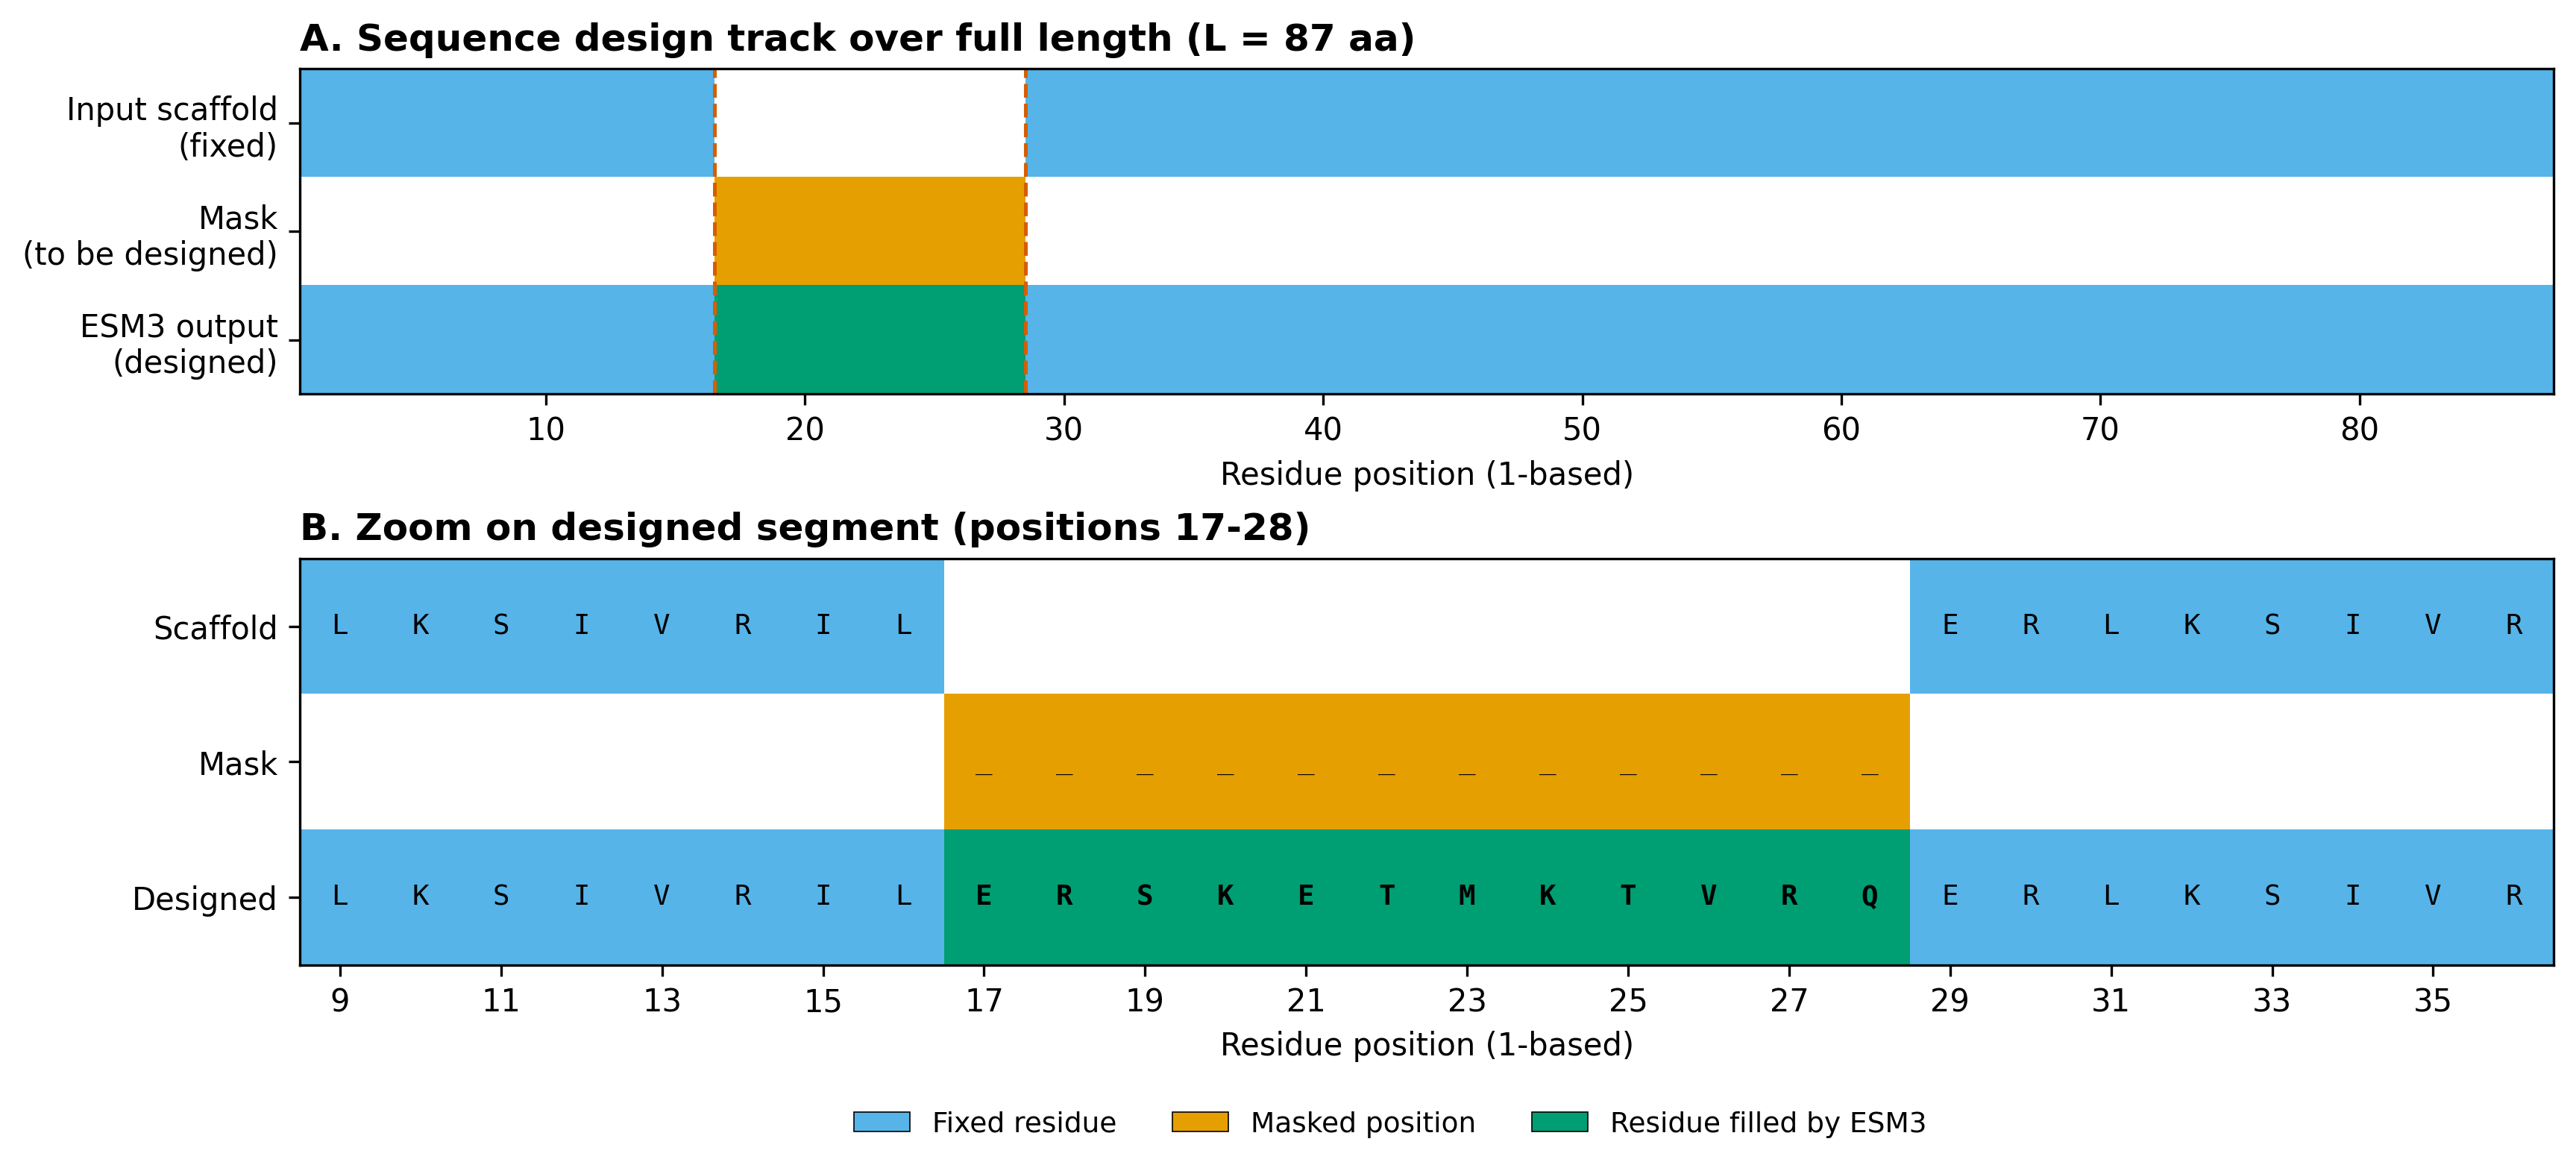

ESM3가 채운 12잔기: ERSKETMKTVRQ
고정 구간 일치 여부: True


In [5]:
# --- 시각화 공통 설정 (이후 셀에서 재사용) -------------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Okabe-Ito colorblind-safe palette
OKABE = {
    "black":  "#000000", "orange": "#E69F00", "skyblue": "#56B4E9",
    "green":  "#009E73", "yellow": "#F0E442", "blue":    "#0072B2",
    "vermil": "#D55E00", "purple":  "#CC79A7", "grey":   "#999999",
}
mpl.rcParams.update({
    "savefig.dpi": 300,
    "figure.dpi": 100,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

# 노트북에 임베드되는 PNG를 300 DPI로 (화면 표시는 브라우저가 축소해 줍니다)
try:
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic(
            "config",
            "InlineBackend.print_figure_kwargs = {'dpi': 300, 'bbox_inches': 'tight'}",
        )
except Exception:
    pass

# --- 설계 구간 인덱스 (0-based) --------------------------------------------
DESIGN_START = len(scaffold)          # 16
DESIGN_LEN   = 12
DESIGN_END   = DESIGN_START + DESIGN_LEN
seq_out = designed.sequence
L = len(seq_out)
assert len(masked_sequence) == L, "입력/출력 길이가 다릅니다"

# 트랙 행렬: 0=없음, 1=고정, 2=마스크, 3=설계로 채워짐
track = np.zeros((3, L), dtype=int)
for i in range(L):
    is_mask = masked_sequence[i] == "_"
    track[0, i] = 0 if is_mask else 1      # scaffold (fixed input)
    track[1, i] = 2 if is_mask else 0      # mask positions
    track[2, i] = 3 if is_mask else 1      # designed output

cmap = ListedColormap(["#FFFFFF", OKABE["skyblue"], OKABE["orange"], OKABE["green"]])

fig = plt.figure(figsize=(13, 5.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.25], hspace=0.45)

# (A) 전체 길이 트랙
axA = fig.add_subplot(gs[0])
axA.imshow(track, cmap=cmap, vmin=0, vmax=3, aspect="auto",
           interpolation="nearest", extent=(0.5, L + 0.5, 2.5, -0.5))
axA.set_yticks([0, 1, 2])
axA.set_yticklabels(["Input scaffold\n(fixed)", "Mask\n(to be designed)", "ESM3 output\n(designed)"])
axA.set_xlabel("Residue position (1-based)")
axA.set_title(f"A. Sequence design track over full length (L = {L} aa)", loc="left", fontweight="bold")
axA.set_xlim(0.5, L + 0.5)
axA.grid(False)
for x in (DESIGN_START + 0.5, DESIGN_END + 0.5):
    axA.axvline(x, color=OKABE["vermil"], lw=1.2, ls="--")
fig.legend(handles=[
    Patch(facecolor=OKABE["skyblue"], edgecolor="k", lw=0.4, label="Fixed residue"),
    Patch(facecolor=OKABE["orange"],  edgecolor="k", lw=0.4, label="Masked position"),
    Patch(facecolor=OKABE["green"],   edgecolor="k", lw=0.4, label="Residue filled by ESM3"),
], loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=3, frameon=False, fontsize=9)

# (B) 설계 구간 확대 (좌우 8잔기 문맥 포함)
pad = 8
lo, hi = max(0, DESIGN_START - pad), min(L, DESIGN_END + pad)
axB = fig.add_subplot(gs[1])
axB.imshow(track[:, lo:hi], cmap=cmap, vmin=0, vmax=3, aspect="auto",
           interpolation="nearest", extent=(lo + 0.5, hi + 0.5, 2.5, -0.5))
axB.set_yticks([0, 1, 2])
axB.set_yticklabels(["Scaffold", "Mask", "Designed"])
axB.set_xticks(range(lo + 1, hi + 1, 2))
axB.set_xlabel("Residue position (1-based)")
axB.set_title(f"B. Zoom on designed segment (positions {DESIGN_START+1}-{DESIGN_END})",
              loc="left", fontweight="bold")
axB.grid(False)
for i in range(lo, hi):
    axB.text(i + 1, 0, masked_sequence[i] if masked_sequence[i] != "_" else "",
             ha="center", va="center", fontsize=9, family="monospace")
    axB.text(i + 1, 1, "_" if masked_sequence[i] == "_" else "",
             ha="center", va="center", fontsize=9, family="monospace")
    axB.text(i + 1, 2, seq_out[i], ha="center", va="center", fontsize=9,
             family="monospace",
             fontweight="bold" if DESIGN_START <= i < DESIGN_END else "normal")

plt.show()

print("ESM3가 채운 12잔기:", seq_out[DESIGN_START:DESIGN_END])
print("고정 구간 일치 여부:",
      seq_out[:DESIGN_START] == masked_sequence[:DESIGN_START]
      and seq_out[DESIGN_END:] == masked_sequence[DESIGN_END:])


### 3-2. 아미노산 조성 비교

설계된 12잔기가 **어떤 아미노산으로 채워졌는지**를 서열 전체 조성과 나란히 놓고 봅니다.
모델이 특정 잔기(예: 소수성 잔기나 helix 선호 잔기)로 치우쳐 채웠는지 확인하는 용도입니다.
설계 구간은 12잔기뿐이므로 빈도의 통계적 해석은 조심해야 합니다 — 경향만 봅니다.

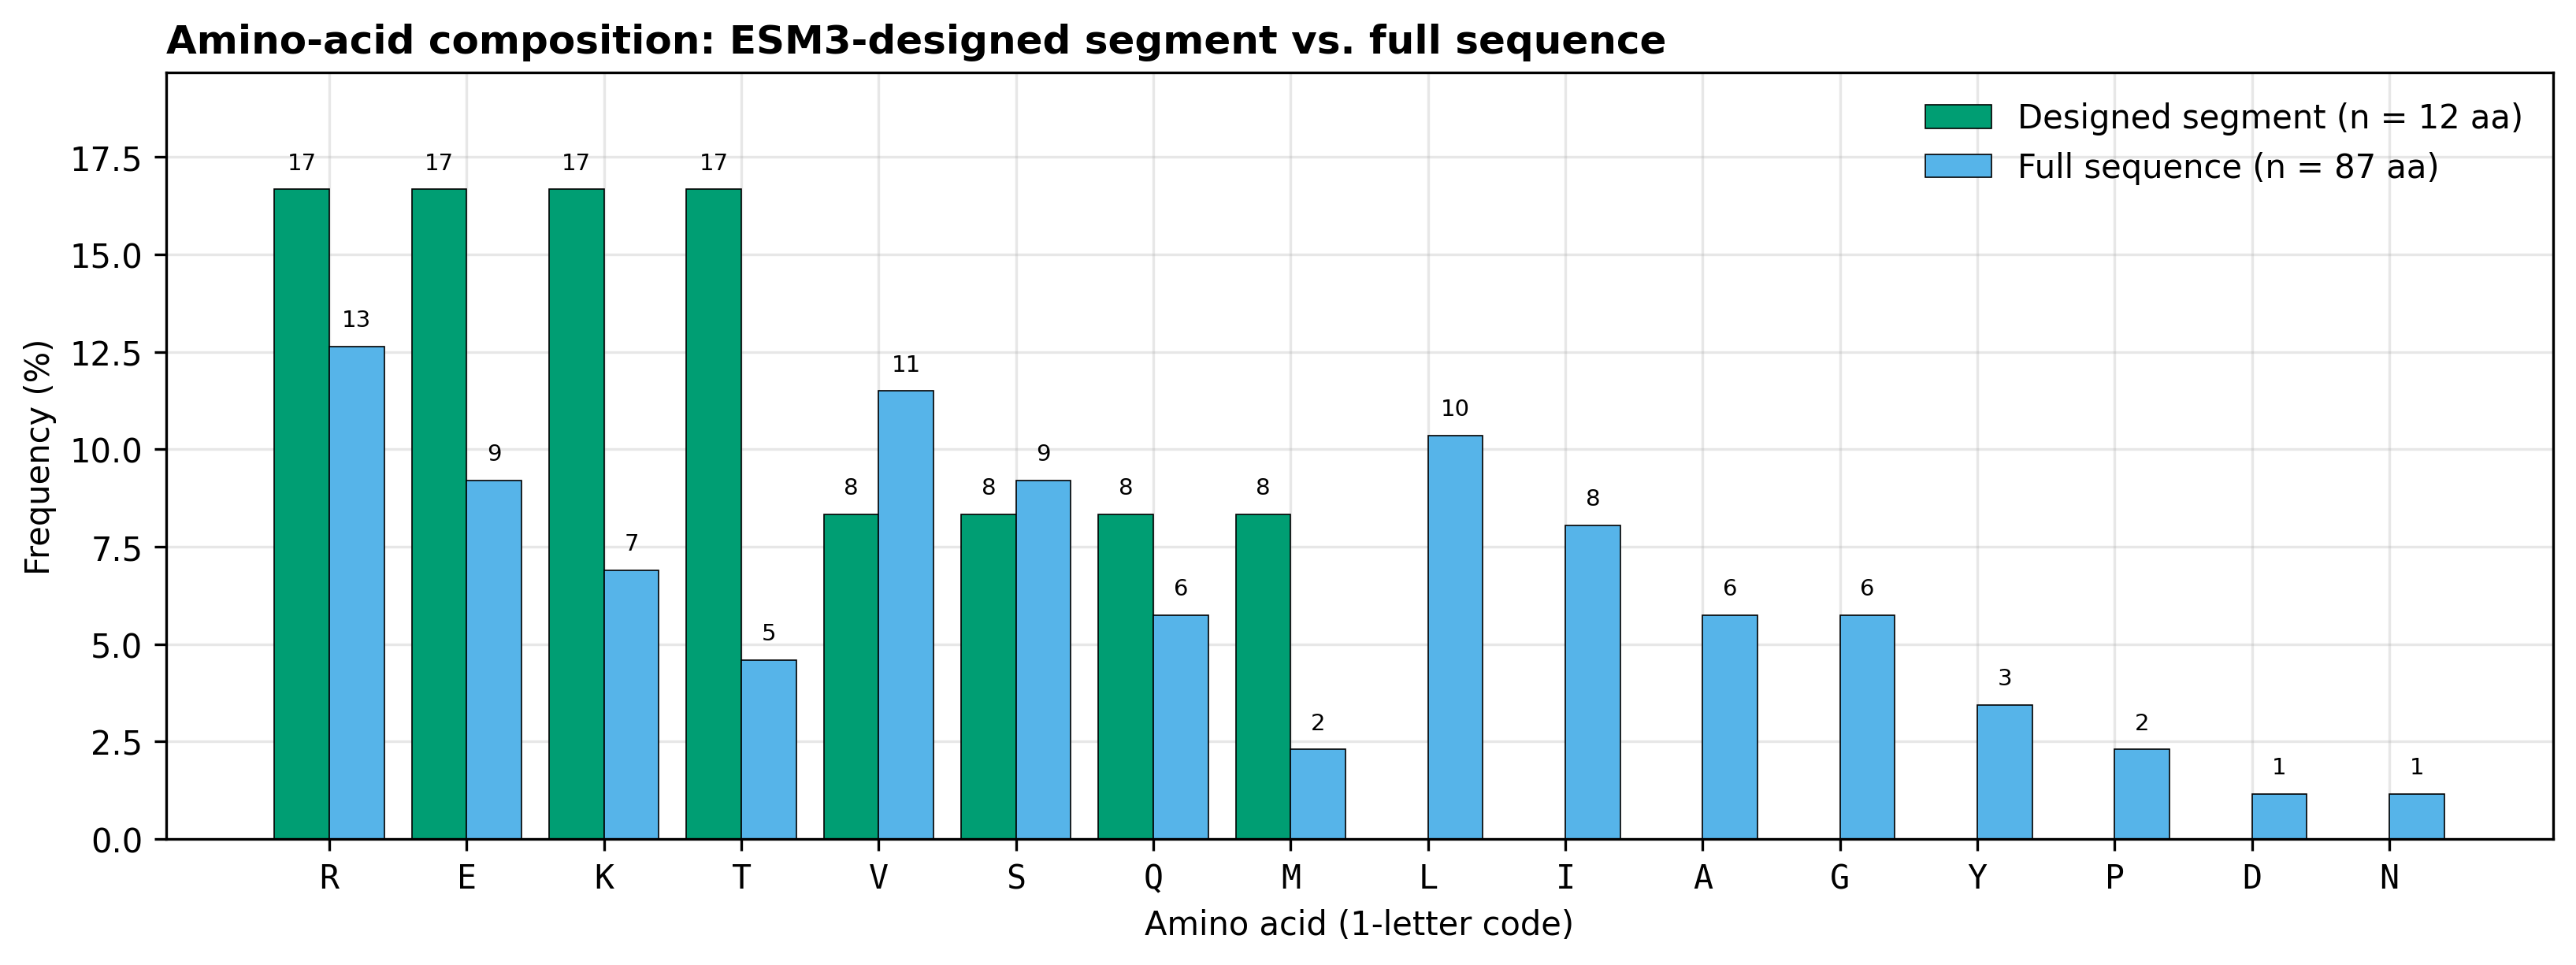

설계 구간 서열      : ERSKETMKTVRQ
소수성 잔기 비율    : 설계 구간 16.7%  /  전체 41.4%
설계 구간 고유 잔기 : 8종 (12자리 중)


In [6]:
from collections import Counter

design_seg = seq_out[DESIGN_START:DESIGN_END]
cnt_design = Counter(design_seg)
cnt_full = Counter(seq_out)

# 두 집합 중 하나라도 등장하는 아미노산만, 설계 구간 빈도 내림차순
aas = sorted(set(cnt_design) | set(cnt_full),
             key=lambda a: (-cnt_design.get(a, 0), -cnt_full.get(a, 0), a))
pct_design = [100.0 * cnt_design.get(a, 0) / len(design_seg) for a in aas]
pct_full = [100.0 * cnt_full.get(a, 0) / len(seq_out) for a in aas]

x = np.arange(len(aas))
w = 0.4

fig, ax = plt.subplots(figsize=(11, 4.2))
b1 = ax.bar(x - w / 2, pct_design, w, label=f"Designed segment (n = {len(design_seg)} aa)",
            color=OKABE["green"], edgecolor="black", linewidth=0.4)
b2 = ax.bar(x + w / 2, pct_full, w, label=f"Full sequence (n = {len(seq_out)} aa)",
            color=OKABE["skyblue"], edgecolor="black", linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(aas, family="monospace")
ax.set_xlabel("Amino acid (1-letter code)")
ax.set_ylabel("Frequency (%)")
ax.set_title("Amino-acid composition: ESM3-designed segment vs. full sequence",
             loc="left", fontweight="bold")
ax.legend(frameon=False)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4, f"{h:.0f}",
                    ha="center", va="bottom", fontsize=7)
ax.set_ylim(0, max(max(pct_design), max(pct_full)) * 1.18)
plt.tight_layout()
plt.show()

hydrophobic = set("AVLIMFWCY")
frac_h_design = 100.0 * sum(1 for a in design_seg if a in hydrophobic) / len(design_seg)
frac_h_full = 100.0 * sum(1 for a in seq_out if a in hydrophobic) / len(seq_out)
print(f"설계 구간 서열      : {design_seg}")
print(f"소수성 잔기 비율    : 설계 구간 {frac_h_design:.1f}%  /  전체 {frac_h_full:.1f}%")
print(f"설계 구간 고유 잔기 : {len(cnt_design)}종 (12자리 중)")


## 4. 서열로부터 구조 예측

같은 모델로 `track="structure"` 를 요청하면 3D 좌표를 생성합니다. 함께 나오는 신뢰도 지표는 AlphaFold와 같은 의미입니다.

- **pLDDT** (0~1): 잔기별 국소 신뢰도. 0.9 이상이면 매우 신뢰할 만합니다.
- **pTM** (0~1): 전체 접힘(fold) 정확도 추정. 0.5 이상이면 대체로 올바른 fold입니다.

In [7]:
# 3절에서 설계한 서열의 구조를 예측합니다
structure_prompt = ESMProtein(sequence=designed.sequence)
predicted = model.generate(
    structure_prompt,
    GenerationConfig(track="structure", num_steps=8),
)

print("좌표 shape:", tuple(predicted.coordinates.shape), "  (잔기 수, 원자 슬롯, xyz)")
print(f"pTM   : {float(predicted.ptm):.3f}")
print(f"pLDDT : {float(predicted.plddt.mean()):.3f} (평균)")

if float(predicted.ptm) < 0.5:
    print("\n주의: pTM이 낮습니다. num_steps를 늘리거나 서열을 다시 설계해 보세요.")

100%|██████████| 8/8 [00:48<00:00,  6.09s/it]


좌표 shape: (87, 37, 3)   (잔기 수, 원자 슬롯, xyz)
pTM   : 0.829
pLDDT : 0.972 (평균)


### 4-1. 잔기별 pLDDT — 새로 만든 부분은 얼마나 믿을 만한가

평균 pLDDT 한 숫자만 보면 **설계 구간의 신뢰도**가 전체 평균에 가려집니다.
아래 그림은 잔기 위치별 pLDDT를 그리고, ESM3가 새로 설계한 구간을 음영으로 표시합니다.
0.7 / 0.9 기준선과 비교해 음영 구간이 어디에 놓이는지가 이 그림의 핵심입니다.

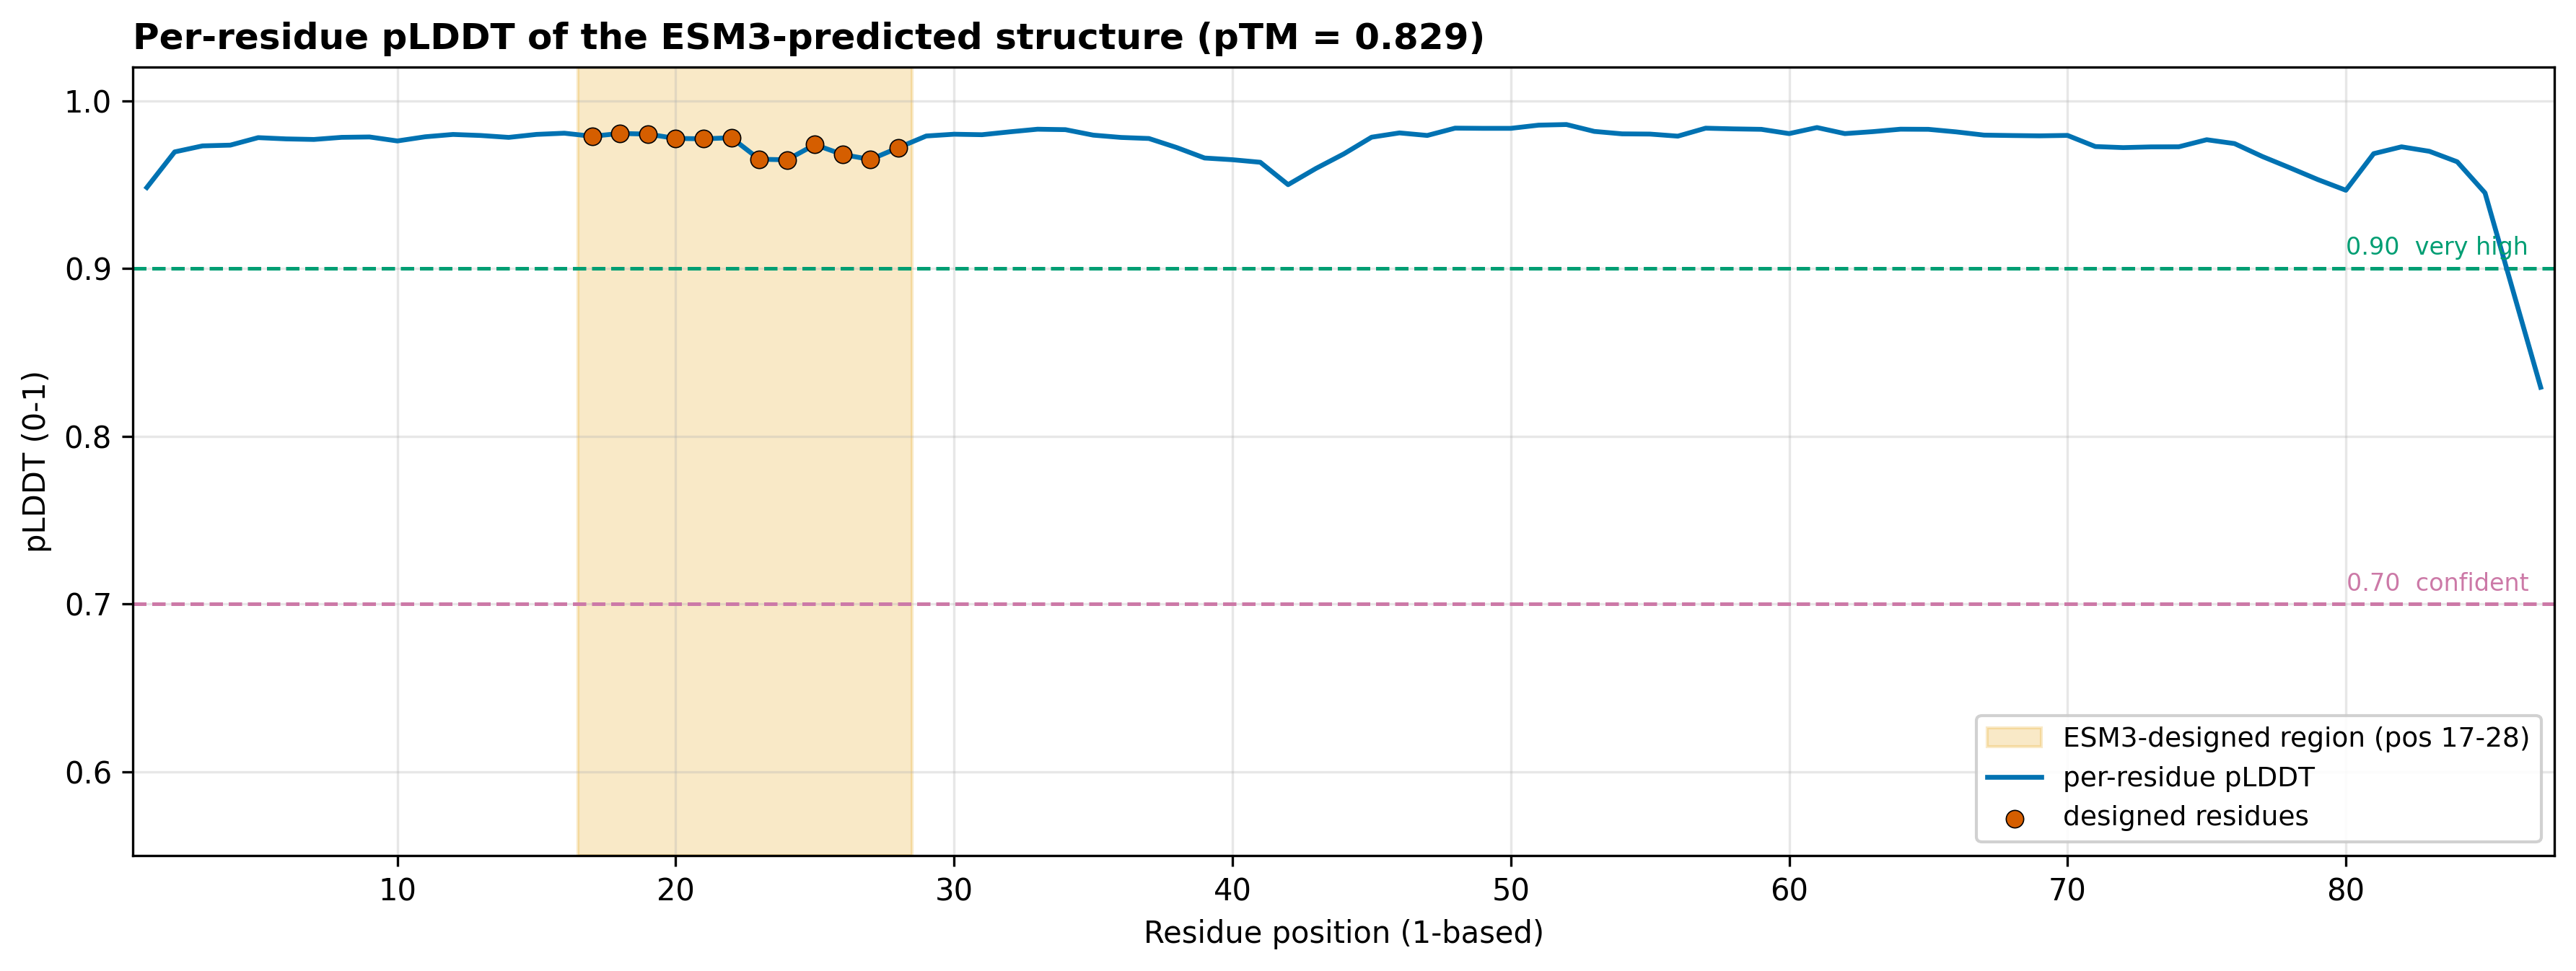

전체 평균 pLDDT      : 0.972
설계 구간 평균 pLDDT : 0.973  (n=12)
고정 구간 평균 pLDDT : 0.972  (n=75)
차이 (설계 - 고정)   : +0.001
설계 구간 최저 pLDDT : 0.965 (위치 24)


In [8]:
plddt = predicted.plddt.detach().cpu().numpy().astype(float).ravel()
pos = np.arange(1, len(plddt) + 1)
assert len(plddt) == L, f"pLDDT 길이({len(plddt)})와 서열 길이({L})가 다릅니다"

design_plddt = plddt[DESIGN_START:DESIGN_END]
fixed_plddt = np.concatenate([plddt[:DESIGN_START], plddt[DESIGN_END:]])

fig, ax = plt.subplots(figsize=(12, 4.6))

# 설계 구간 음영
ax.axvspan(DESIGN_START + 0.5, DESIGN_END + 0.5, color=OKABE["orange"], alpha=0.22, zorder=0,
           label=f"ESM3-designed region (pos {DESIGN_START+1}-{DESIGN_END})")

ax.plot(pos, plddt, "-", color=OKABE["blue"], lw=1.6, zorder=3, label="per-residue pLDDT")
ax.scatter(pos[DESIGN_START:DESIGN_END], design_plddt, s=34, color=OKABE["vermil"],
           edgecolor="black", linewidth=0.4, zorder=4, label="designed residues")

ax.axhline(0.9, color=OKABE["green"], ls="--", lw=1.2, zorder=2)
ax.axhline(0.7, color=OKABE["purple"], ls="--", lw=1.2, zorder=2)
ax.text(L * 0.995, 0.905, "0.90  very high", ha="right", va="bottom",
        fontsize=8, color=OKABE["green"])
ax.text(L * 0.995, 0.705, "0.70  confident", ha="right", va="bottom",
        fontsize=8, color=OKABE["purple"])

ax.set_xlabel("Residue position (1-based)")
ax.set_ylabel("pLDDT (0-1)")
ax.set_xlim(0.5, L + 0.5)
ax.set_ylim(min(0.55, plddt.min() - 0.05), 1.02)
ax.set_title(f"Per-residue pLDDT of the ESM3-predicted structure "
             f"(pTM = {float(predicted.ptm):.3f})", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=True, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

print(f"전체 평균 pLDDT      : {plddt.mean():.3f}")
print(f"설계 구간 평균 pLDDT : {design_plddt.mean():.3f}  (n={len(design_plddt)})")
print(f"고정 구간 평균 pLDDT : {fixed_plddt.mean():.3f}  (n={len(fixed_plddt)})")
print(f"차이 (설계 - 고정)   : {design_plddt.mean() - fixed_plddt.mean():+.3f}")
print(f"설계 구간 최저 pLDDT : {design_plddt.min():.3f} "
      f"(위치 {DESIGN_START + 1 + int(design_plddt.argmin())})")


### 4-2. pLDDT 분포와 신뢰도 구간 비율

같은 값을 분포로 봅니다. 왼쪽은 히스토그램(설계 구간을 따로 겹쳐 그림),
오른쪽은 `매우 높음(≥0.9) / 높음(0.7-0.9) / 낮음(<0.7)` 세 구간의 잔기 비율입니다.
"평균이 높다"와 "낮은 잔기가 하나도 없다"는 다른 이야기라서 둘 다 봅니다.

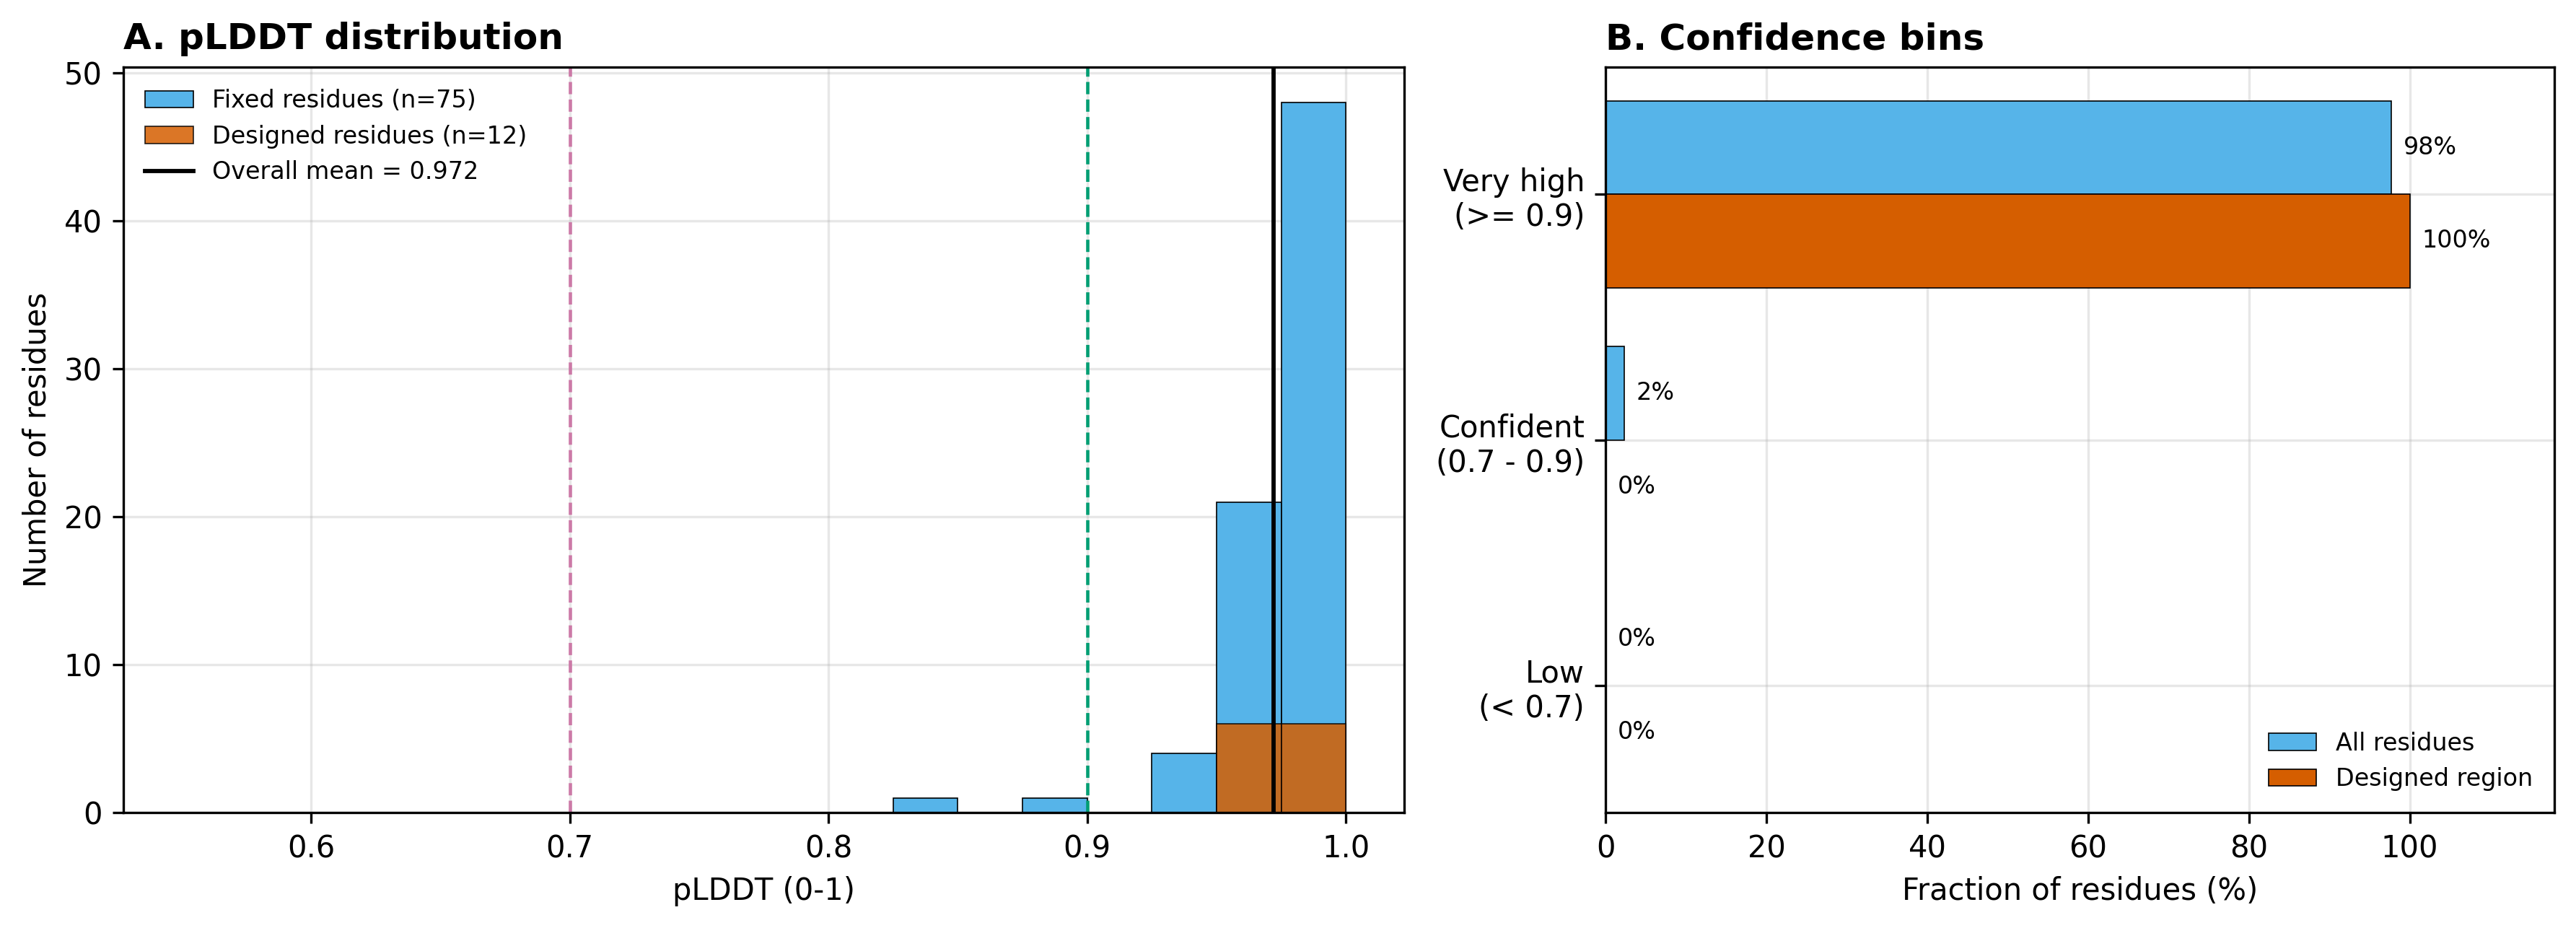

Very high (>= 0.9)     전체  97.7%   설계 구간 100.0%
Confident (0.7 - 0.9)  전체   2.3%   설계 구간   0.0%
Low (< 0.7)            전체   0.0%   설계 구간   0.0%


In [9]:
BINS = [("Very high\n(>= 0.9)", 0.9, 1.01, OKABE["blue"]),
        ("Confident\n(0.7 - 0.9)", 0.7, 0.9, OKABE["skyblue"]),
        ("Low\n(< 0.7)", -0.01, 0.7, OKABE["vermil"])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4),
                               gridspec_kw={"width_ratios": [1.35, 1.0]})

# (좌) 히스토그램
edges = np.linspace(min(0.55, plddt.min() - 0.02), 1.0, 19)
ax1.hist(fixed_plddt, bins=edges, color=OKABE["skyblue"], edgecolor="black",
         linewidth=0.4, label=f"Fixed residues (n={len(fixed_plddt)})")
ax1.hist(design_plddt, bins=edges, color=OKABE["vermil"], edgecolor="black",
         linewidth=0.4, alpha=0.85, label=f"Designed residues (n={len(design_plddt)})")
ax1.axvline(plddt.mean(), color=OKABE["black"], ls="-", lw=1.4,
            label=f"Overall mean = {plddt.mean():.3f}")
ax1.axvline(0.9, color=OKABE["green"], ls="--", lw=1.1)
ax1.axvline(0.7, color=OKABE["purple"], ls="--", lw=1.1)
ax1.set_xlabel("pLDDT (0-1)")
ax1.set_ylabel("Number of residues")
ax1.set_title("A. pLDDT distribution", loc="left", fontweight="bold")
ax1.legend(fontsize=8, frameon=False)

# (우) 신뢰도 구간별 비율
labels = [b[0] for b in BINS]
frac_all, frac_des = [], []
for _, lo_, hi_, _c in BINS:
    frac_all.append(100.0 * np.sum((plddt >= lo_) & (plddt < hi_)) / len(plddt))
    frac_des.append(100.0 * np.sum((design_plddt >= lo_) & (design_plddt < hi_)) / len(design_plddt))

y = np.arange(len(labels))
h = 0.38
ax2.barh(y - h / 2, frac_all, h, color=OKABE["skyblue"], edgecolor="black",
         linewidth=0.4, label="All residues")
ax2.barh(y + h / 2, frac_des, h, color=OKABE["vermil"], edgecolor="black",
         linewidth=0.4, label="Designed region")
for yi, (fa, fd) in enumerate(zip(frac_all, frac_des)):
    ax2.text(fa + 1.5, yi - h / 2, f"{fa:.0f}%", va="center", fontsize=8)
    ax2.text(fd + 1.5, yi + h / 2, f"{fd:.0f}%", va="center", fontsize=8)
ax2.set_yticks(y)
ax2.set_yticklabels(labels)
ax2.invert_yaxis()
ax2.set_xlim(0, 118)
ax2.set_xlabel("Fraction of residues (%)")
ax2.set_title("B. Confidence bins", loc="left", fontweight="bold")
ax2.legend(fontsize=8, frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

for (label, lo_, hi_, _c), fa, fd in zip(BINS, frac_all, frac_des):
    print(f"{label.replace(chr(10), ' '):<22} 전체 {fa:5.1f}%   설계 구간 {fd:5.1f}%")


## 5. 예측 구조 시각화

`ESMProtein.to_pdb_string()` 으로 PDB 텍스트를 얻어 py3Dmol에 바로 올립니다.
(nglview는 Colab에서 렌더링되지 않아 이 워크숍의 다른 노트북과 동일하게 py3Dmol을 씁니다)

pLDDT로 색을 칠하면 어느 구간을 모델이 확신하는지 한눈에 보입니다.

In [10]:
import py3Dmol

pdb_string = predicted.to_pdb_string()
print(f"PDB 텍스트 {len(pdb_string):,}자, ATOM 줄 {pdb_string.count(chr(10) + 'ATOM'):,}개")

# to_pdb_string() 은 B-factor 열에 pLDDT를 **0~100 스케일**로 씁니다
# (predicted.plddt 텐서는 0~1 스케일이라 단위가 다릅니다 - 색 범위를 0~100 으로 맞춰야 합니다)
b_values = [float(line[60:66]) for line in pdb_string.split("\n") if line.startswith("ATOM")]
print(f"B-factor(pLDDT) 범위: {min(b_values):.1f} ~ {max(b_values):.1f}")

view = py3Dmol.view(width=900, height=600)
view.addModel(pdb_string, "pdb")

# pLDDT 기반 색칠 (B-factor 열 0~100)
view.setStyle({}, {"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 0, "max": 100}}})

# ESM3가 새로 설계한 구간을 stick으로 강조
designed_region = list(range(len(scaffold) + 1, len(scaffold) + 13))  # PDB 잔기 번호는 1부터
view.addStyle({"resi": designed_region}, {"stick": {"radius": 0.15}})

view.zoomTo()
view.show()

print("색: 빨강(pLDDT 낮음) -> 파랑(pLDDT 높음) / stick: ESM3가 설계한 12잔기")

PDB 텍스트 28,106자, ATOM 줄 346개
B-factor(pLDDT) 범위: 82.9 ~ 98.6


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

색: 빨강(pLDDT 낮음) -> 파랑(pLDDT 높음) / stick: ESM3가 설계한 12잔기


## 6. 여러 번 생성해 보기 — 확률적 생성이라는 뜻

ESM3의 `generate()` 는 **결정론적이지 않습니다**. 같은 마스크를 줘도 `num_steps` 와
`temperature` 에 따라 다른 서열이 나오고, 그 서열의 예측 구조 신뢰도도 달라집니다.
아래는 세 가지 설정으로 각각 서열 설계 + 구조 예측을 다시 수행해 pTM / 평균 pLDDT를
비교합니다 (CPU 기준 약 45초). 설계 결과 하나만 보고 결론 내리면 안 되는 이유를 보여주는 그림입니다.

100%|██████████| 8/8 [00:50<00:00,  6.32s/it]


steps=4, T=0.3   segment=ERSKETMKTVRQ  pTM=0.851  pLDDT(all)=0.978  pLDDT(designed)=0.978  [87s]


100%|██████████| 8/8 [00:49<00:00,  6.18s/it]


steps=8, T=0.7   segment=ERSKEPMKTVRQ  pTM=0.846  pLDDT(all)=0.976  pLDDT(designed)=0.979  [111s]


100%|██████████| 8/8 [00:51<00:00,  6.38s/it]


steps=16, T=1.0  segment=ERSKETMKTVRQ  pTM=0.819  pLDDT(all)=0.967  pLDDT(designed)=0.965  [139s]


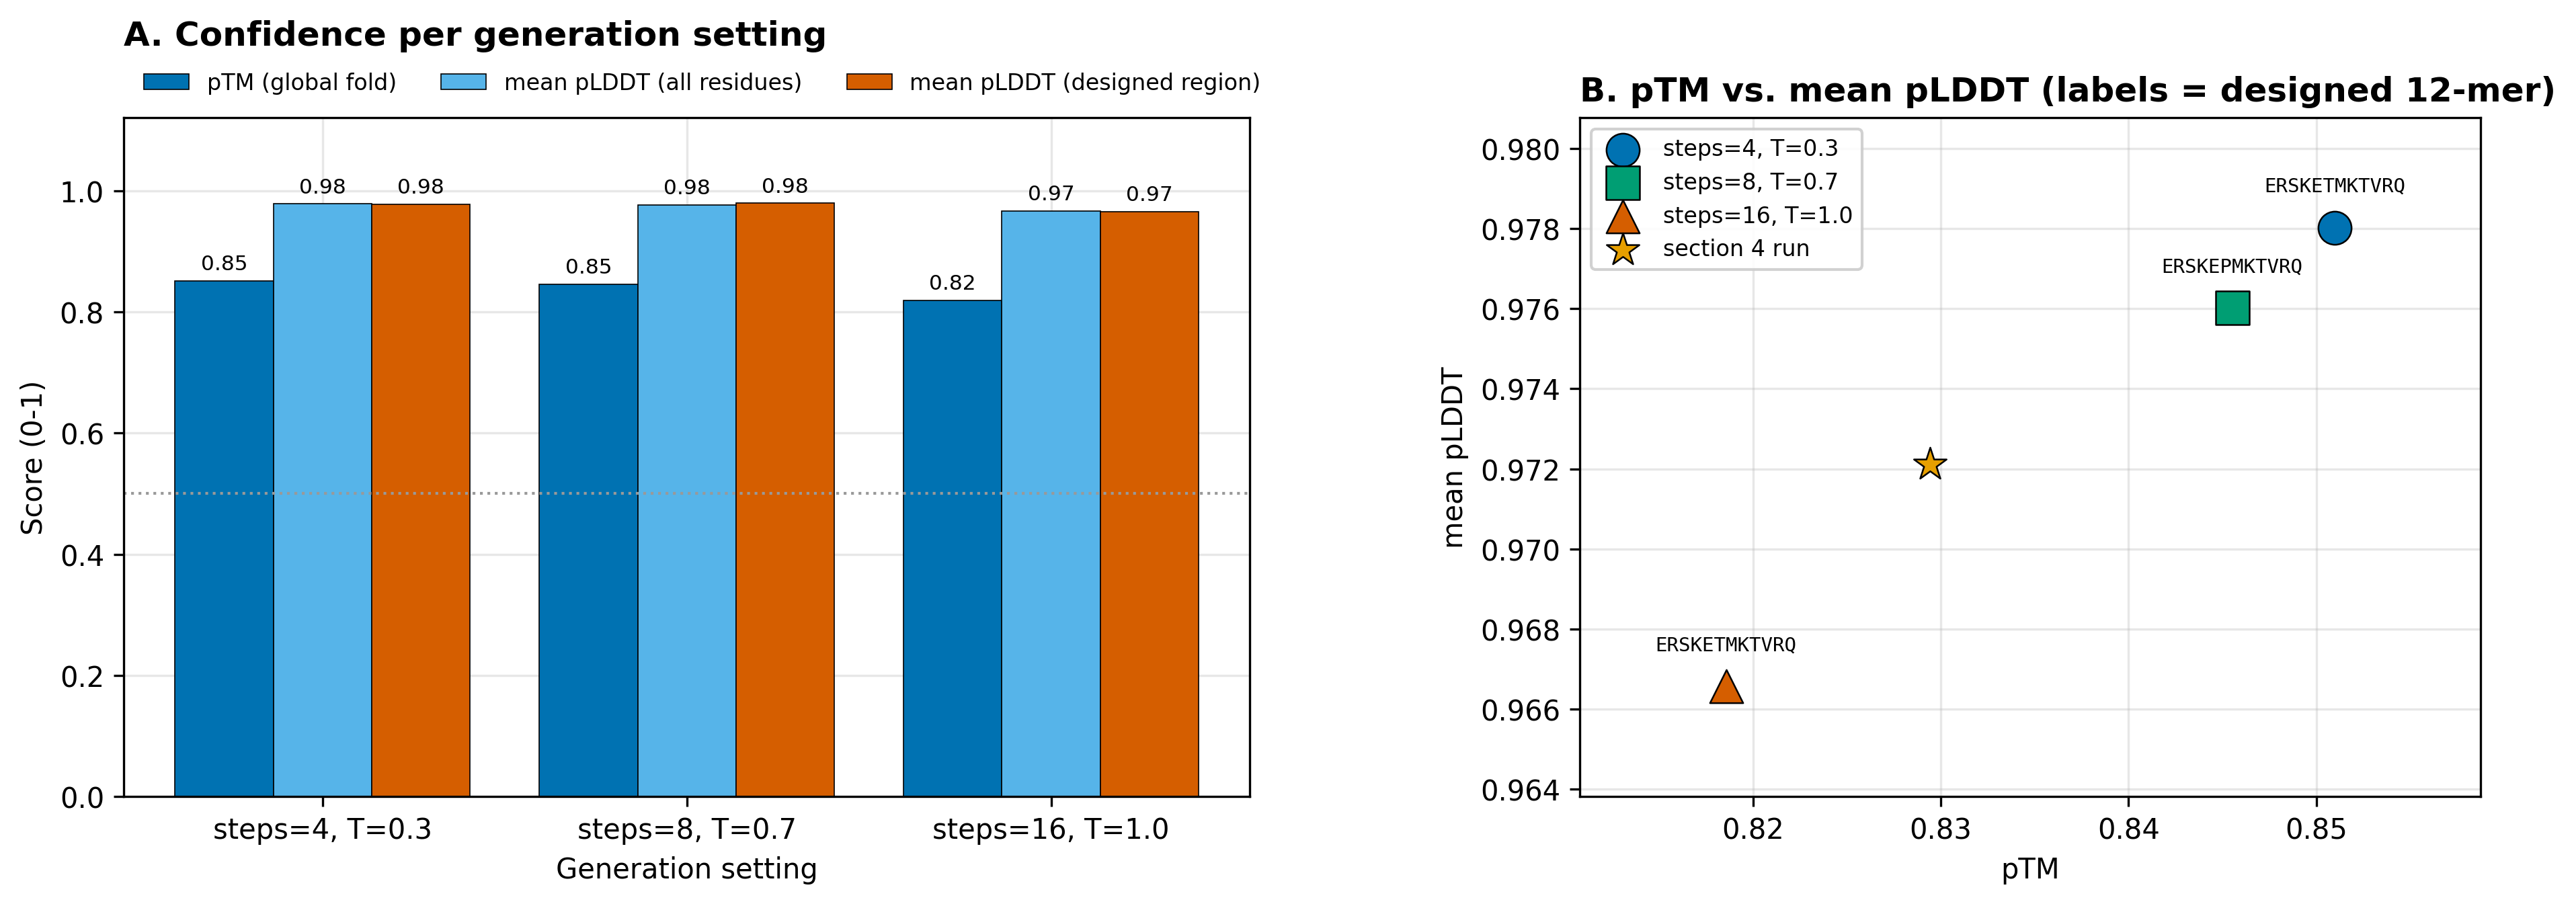


총 4회 생성에서 서로 다른 설계 서열: 2종 -> 생성은 확률적입니다
pTM 범위        : 0.819 ~ 0.851
평균 pLDDT 범위 : 0.967 ~ 0.978


In [11]:
import time

RUNS = [
    {"label": "steps=4, T=0.3",  "num_steps": 4,  "temperature": 0.3},
    {"label": "steps=8, T=0.7",  "num_steps": 8,  "temperature": 0.7},
    {"label": "steps=16, T=1.0", "num_steps": 16, "temperature": 1.0},
]

multi_results = []
for cfg in RUNS:
    t0 = time.time()
    d = model.generate(
        ESMProtein(sequence=masked_sequence),
        GenerationConfig(track="sequence", num_steps=cfg["num_steps"],
                         temperature=cfg["temperature"]),
    )
    p = model.generate(
        ESMProtein(sequence=d.sequence),
        GenerationConfig(track="structure", num_steps=8),
    )
    pl = p.plddt.detach().cpu().numpy().astype(float).ravel()
    multi_results.append({
        "label": cfg["label"],
        "segment": d.sequence[DESIGN_START:DESIGN_END],
        "ptm": float(p.ptm),
        "plddt_mean": float(pl.mean()),
        "plddt_design": float(pl[DESIGN_START:DESIGN_END].mean()),
        "sec": time.time() - t0,
    })
    print(f"{cfg['label']:<16} segment={multi_results[-1]['segment']}  "
          f"pTM={multi_results[-1]['ptm']:.3f}  "
          f"pLDDT(all)={multi_results[-1]['plddt_mean']:.3f}  "
          f"pLDDT(designed)={multi_results[-1]['plddt_design']:.3f}  "
          f"[{multi_results[-1]['sec']:.0f}s]")

labels = [r["label"] for r in multi_results]
ptms = [r["ptm"] for r in multi_results]
pl_all = [r["plddt_mean"] for r in multi_results]
pl_des = [r["plddt_design"] for r in multi_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6),
                               gridspec_kw={"width_ratios": [1.25, 1.0]})

x = np.arange(len(labels))
w = 0.27
ax1.bar(x - w, ptms, w, label="pTM (global fold)", color=OKABE["blue"],
        edgecolor="black", linewidth=0.4)
ax1.bar(x, pl_all, w, label="mean pLDDT (all residues)", color=OKABE["skyblue"],
        edgecolor="black", linewidth=0.4)
ax1.bar(x + w, pl_des, w, label="mean pLDDT (designed region)", color=OKABE["vermil"],
        edgecolor="black", linewidth=0.4)
for xi, vals in zip(x, zip(ptms, pl_all, pl_des)):
    for dx, v in zip((-w, 0, w), vals):
        ax1.text(xi + dx, v + 0.012, f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Score (0-1)")
ax1.set_ylim(0, 1.12)
ax1.axhline(0.5, color=OKABE["grey"], ls=":", lw=1.0)
ax1.set_xlabel("Generation setting")
ax1.set_title("A. Confidence per generation setting", loc="left",
              fontweight="bold", pad=26)
ax1.legend(fontsize=8, frameon=False, ncol=3, loc="lower left",
           bbox_to_anchor=(0.0, 1.005))

markers = ["o", "s", "^"]
for r, m, c in zip(multi_results, markers,
                   [OKABE["blue"], OKABE["green"], OKABE["vermil"]]):
    ax2.scatter(r["ptm"], r["plddt_mean"], s=140, marker=m, color=c,
                edgecolor="black", linewidth=0.6, label=r["label"], zorder=3)
    ax2.annotate(r["segment"], (r["ptm"], r["plddt_mean"]), textcoords="offset points",
                 xytext=(0, 13), ha="center", fontsize=7, family="monospace")
ax2.scatter(float(predicted.ptm), float(plddt.mean()), s=150, marker="*",
            color=OKABE["orange"], edgecolor="black", linewidth=0.6,
            label="section 4 run", zorder=3)
ax2.set_xlabel("pTM")
ax2.set_ylabel("mean pLDDT")
ax2.set_title("B. pTM vs. mean pLDDT (labels = designed 12-mer)",
              loc="left", fontweight="bold")
ax2.margins(0.24)
ax2.legend(fontsize=8, frameon=True, framealpha=0.9, loc="upper left")
plt.tight_layout()
plt.show()

uniq = {r["segment"] for r in multi_results} | {seq_out[DESIGN_START:DESIGN_END]}
print(f"\n총 4회 생성에서 서로 다른 설계 서열: {len(uniq)}종 -> 생성은 확률적입니다")
print(f"pTM 범위        : {min(ptms):.3f} ~ {max(ptms):.3f}")
print(f"평균 pLDDT 범위 : {min(pl_all):.3f} ~ {max(pl_all):.3f}")


## 7. 한계와 주의

**확인한 것**

- 마스크 구간 서열 설계와 구조 예측이 동일한 모델에서 동작한다.
- CPU에서도 각 단계가 15초 내외다 (1.4B open 모델, float32 기준).

**정직하게 남는 한계**

- **소형 공개 모델이다.** `esm3_sm_open_v1` 은 1.4B 파라미터의 공개 체크포인트이고, 논문의 대형
  모델(98B)은 [Forge API](https://forge.evolutionaryscale.ai/) 로만 접근할 수 있다. 성능이 다르다.
- **예측 구조는 모델의 추정이다.** pLDDT·pTM 이 높다는 것은 모델이 확신한다는 뜻이지 구조가 맞다는
  뜻이 아니다. 실제 검증에는 발현·결합·열안정성 실험이 필요하다.
- **결과가 실행마다 달라진다.** `generate()` 는 결정론적이지 않아 같은 마스크에서도 다른 서열이 나온다
  (6절에서 직접 확인). 설계 결과 하나만 보고 결론 내리면 안 된다.
- **설계 구간이 12잔기뿐이다.** 3-2절 조성 비교의 빈도는 표본이 12개라 통계적 해석이 불가능하고,
  경향 이상으로 읽으면 안 된다.
- **기능(function) 트랙은 다루지 않았다.** InterPro 키워드 기반 기능 조건화는 이 노트북 범위 밖이다.
- **예시 서열은 실제 PDE5A가 아니다.** 방법 시연용 일반 스캐폴드이므로, 여기서 나온 서열·구조를
  PDE5A에 대한 결과로 인용하면 안 된다.
- **dtype 캐스팅이 필요하다.** 체크포인트가 bfloat16이라 `model.to(torch.float32)` 를 넣었다(2절 참조).
  빼면 `mat1 and mat2 must have the same dtype` 오류가 난다.


## 8. 다음 실습

6일차의 다른 노트북으로 이어진다.

- [`t110_esm2_peptide_optimization_tutorial.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t110_esm2_peptide_optimization_tutorial.ipynb)
  — ESM-2 기반 펩타이드 결합 최적화. 생성형 대신 **masked-LM 로짓을 직접 스코어링**하는 접근을 비교해 본다.
- [`t042_molt5.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t042_molt5.ipynb)
  — 화학 언어모델(분자 ↔ 텍스트). 같은 "생성 결과는 반드시 검증한다"는 문제의식의 분자 버전.
- [`t050_simple-local-rag.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t050_simple-local-rag.ipynb)
  — 모델의 주장을 문헌 근거에 묶는 RAG 파이프라인.
